# Redfield Relaxation Theory in Quantarhei

## Open quantum systems and the density matrix

A molecular aggregate in a condensed-phase environment is an **open quantum system**: the chromophores of interest (the *system*) are weakly coupled to many vibrational degrees of freedom of the surrounding protein or solvent (the *bath*).  The exact quantum state of the system is captured by the **reduced density matrix**

$$
\hat{\rho}(t) = \mathrm{Tr}_{\mathrm{bath}}\bigl[\hat{\rho}_{\mathrm{total}}(t)\bigr],
$$

whose diagonal elements $\rho_{nn}(t)$ are the **populations** of the energy eigenstates and whose off-diagonal elements are **coherences**.

## Redfield theory

When the system–bath coupling is weak (Born approximation) and memory effects are negligible (Markov approximation), the evolution of $\hat{\rho}$ is governed by the **Redfield equation**

$$
\frac{d\hat{\rho}}{dt} = -\frac{i}{\hbar}[\hat{H},\hat{\rho}] + \mathcal{R}\,\hat{\rho},
$$

where $\mathcal{R}$ is the **Redfield relaxation tensor** — a rank-4 object in Liouville space whose elements are determined by the spectral density of the bath fluctuations.  After a *secular* (rotating-wave) approximation the populations decouple from the coherences and relax independently.

In this notebook we:
1. Build a **homodimer** aggregate (two identical chromophores) with an Overdamped Brownian oscillator bath.
2. Compute the **Redfield relaxation tensor** in the exciton basis.
3. **Propagate** the density matrix from an initially excited single exciton state.
4. Plot the **population dynamics** and verify relaxation toward the thermal equilibrium predicted by Boltzmann statistics.
5. Tabulate the **relaxation rates** from both the full tensor and the rate matrix.

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/tmancal74/quantarhei/master?labpath=examples/notebooks/04_redfield_relaxation.ipynb)
*Click the badge to run this notebook interactively in your browser — no installation required.*

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import numpy
import matplotlib.pyplot as plt

import quantarhei as qr
from quantarhei.models.modelgenerator import ModelGenerator

## 1. Build a homodimer aggregate with a bath

We use the built-in `ModelGenerator` to create a **dimer** whose two molecules each have a single excited electronic state.  Each chromophore is coupled to an **Overdamped Brownian oscillator** bath characterised by:

| Parameter | Value | Description |
|-----------|-------|-------------|
| `reorg`   | 100 cm⁻¹ | Reorganisation energy |
| `cortime` | 100 fs   | Bath correlation time |
| `T`       | 300 K    | Temperature |

The two-molecule system (plus the common ground state) gives a **3 × 3 Hilbert space** (index 0 = ground, 1 and 2 = single-exciton states).

In [2]:
Nt = 500      # number of time steps
dt = 1.0      # time step in femtoseconds
time = qr.TimeAxis(0.0, Nt, dt)

mg  = ModelGenerator()
agg = mg.get_Aggregate_with_environment(name='dimer-1_env', timeaxis=time)
agg.build()

sbi = agg.get_SystemBathInteraction()
ham = agg.get_Hamiltonian()

with qr.energy_units('1/cm'):
    print('Hamiltonian (1/cm):')
    print(ham)


quantarhei.ValueAxis object
start = 0.0
length = 500
step = 1.0
Hamiltonian (1/cm):

quantarhei.Hamiltonian object
units of energy 1/cm
Rotating Wave Approximation (RWA) enabled : True
Number of blocks : 2
Block average energies:
 0 : 0.0
 1 : 10075.0
data =
[[     0.              0.              0.        ]
 [     0.          10100.           -100.35418153]
 [     0.           -100.35418153  10050.        ]]


## 2. Compute the Redfield relaxation tensor

All relaxation calculations are done **in the exciton (energy) basis** obtained by diagonalising $\hat{H}$.  The context manager `qr.eigenbasis_of(ham)` transforms all operators automatically.

We suppress the basis-change warning because `protect_basis()` / `eigenbasis_of` coordinates the rotation internally.

In [3]:
m = qr.Manager()
m.warn_about_basis_change = False

# Reference operator that remembers the site basis
sb_reference = qr.BasisReferenceOperator(ham.dim, name='site basis reference')

ham.protect_basis()
with qr.eigenbasis_of(ham):
    # Full Redfield relaxation tensor
    RRT = qr.qm.RedfieldRelaxationTensor(ham, sbi, name='Tensor 1')

    # Redfield rate matrix (secular limit — populations only)
    RRM = qr.qm.RedfieldRateMatrix(ham, sbi)

    print('Redfield relaxation tensor computed.')
    print('Dimensions:', RRT.data.shape)

Redfield relaxation tensor computed.
Dimensions: (3, 3, 3, 3)


## 3. Propagate the density matrix

We prepare the system in the **first exciton state** ($\rho_{11}=1$, all other elements zero) and propagate under the secular Redfield equation.  `RRT.secularize()` removes the off-diagonal Liouville-space elements that couple populations to coherences, which is valid when the exciton splitting is large compared with the relaxation rates.

The propagator uses a short-exponential expansion of the Liouvillian (4th-order by default).

In [4]:
ham.unprotect_basis()
with qr.eigenbasis_of(ham):
    # Secularise: decouple populations from coherences
    RRT.secularize()

    # Build propagator
    prop = qr.ReducedDensityMatrixPropagator(time, ham, RRT)

    # Initial density matrix: exciton 1 fully populated
    rho_i = qr.ReducedDensityMatrix(dim=ham.dim, name='Initial DM')
    rho_i.data[1, 1] = 1.0

    # Propagate (note: no 'name=' keyword)
    rho_t = prop.propagate(rho_i)

print('rho_t.data shape:', rho_t.data.shape)   # (Nt, dim, dim)
print('Final populations (t = 499 fs):')
for i in range(ham.dim):
    print(f'  rho_{i}{i} = {numpy.real(rho_t.data[-1, i, i]):.4f}')

rho_t.data shape: (500, 3, 3)
Final populations (t = 499 fs):
  rho_00 = 0.0000
  rho_11 = 0.4451
  rho_22 = 0.5549


### Thermal equilibrium check

At long times the Boltzmann distribution over the two exciton states (energies $E_1 = 10100$ cm⁻¹ and $E_2 = 10050$ cm⁻¹, $T = 300$ K) gives

$$
\rho_{11}^{\rm eq} = \frac{e^{-E_1/k_BT}}{e^{-E_1/k_BT}+e^{-E_2/k_BT}}, \qquad \rho_{22}^{\rm eq} = \frac{e^{-E_2/k_BT}}{e^{-E_1/k_BT}+e^{-E_2/k_BT}}.
$$

Because $E_2 < E_1$ the lower exciton (state 2) is slightly more populated at equilibrium.

In [5]:
kB_hc = 0.6950356  # k_B / (h c) in cm^{-1} K^{-1}
T = 300.0
E1, E2 = 10100.0, 10050.0   # cm^{-1} in exciton basis (site energies; exciton splitting is small)

Z = numpy.exp(-E1 / (kB_hc * T)) + numpy.exp(-E2 / (kB_hc * T))
rho_eq_1 = numpy.exp(-E1 / (kB_hc * T)) / Z
rho_eq_2 = numpy.exp(-E2 / (kB_hc * T)) / Z

print(f'Boltzmann rho_11_eq = {rho_eq_1:.4f}')
print(f'Boltzmann rho_22_eq = {rho_eq_2:.4f}')
print(f'Propagated rho_11   = {numpy.real(rho_t.data[-1, 1, 1]):.4f}')
print(f'Propagated rho_22   = {numpy.real(rho_t.data[-1, 2, 2]):.4f}')

Boltzmann rho_11_eq = 0.4403
Boltzmann rho_22_eq = 0.5597
Propagated rho_11   = 0.4451
Propagated rho_22   = 0.5549


## 4. Population dynamics

The plot below shows both exciton populations as a function of time.  Dashed horizontal lines mark the Boltzmann equilibrium values.

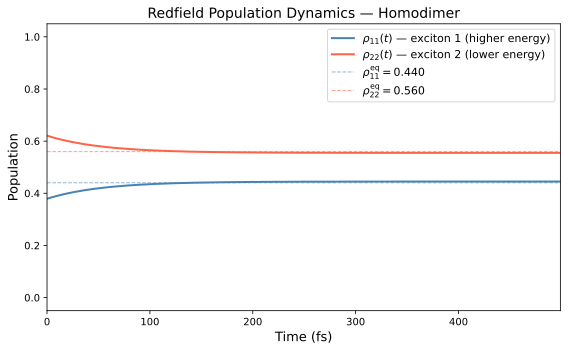

In [6]:
t_fs = rho_t.TimeAxis.data

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t_fs, numpy.real(rho_t.data[:, 1, 1]),
        label=r'$\rho_{11}(t)$ — exciton 1 (higher energy)',
        color='steelblue', linewidth=2)
ax.plot(t_fs, numpy.real(rho_t.data[:, 2, 2]),
        label=r'$\rho_{22}(t)$ — exciton 2 (lower energy)',
        color='tomato', linewidth=2)

ax.axhline(rho_eq_1, color='steelblue', linestyle='--', linewidth=1,
           alpha=0.6, label=fr'$\rho_{{11}}^{{\rm eq}}={rho_eq_1:.3f}$')
ax.axhline(rho_eq_2, color='tomato',    linestyle='--', linewidth=1,
           alpha=0.6, label=fr'$\rho_{{22}}^{{\rm eq}}={rho_eq_2:.3f}$')

ax.set_xlabel('Time (fs)', fontsize=13)
ax.set_ylabel('Population', fontsize=13)
ax.set_title('Redfield Population Dynamics — Homodimer', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(0, 499)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## 5. Relaxation rates

Redfield theory gives two equivalent ways to extract transition rates:

* **Full tensor** $\mathcal{R}_{nnmm}$: the diagonal elements of the Redfield tensor in Liouville space give the rate from state $m$ to state $n$.
* **Rate matrix** $K_{nm}$ (`RedfieldRateMatrix`): the secular rate matrix computed directly from the bath spectral density — numerically slightly faster and identical in the secular limit.

Both must satisfy **detailed balance**: $K_{nm}/K_{mn} = e^{(E_m - E_n)/k_BT}$.

In [7]:
print('=== Relaxation rates from the full Redfield tensor ===')
print(f'  rate(1←2) = R[1,1,2,2] = {numpy.real(RRT.data[1,1,2,2]):.6f} fs⁻¹  '
      f'  τ = {1.0/numpy.real(RRT.data[1,1,2,2]):.1f} fs')
print(f'  rate(2←1) = R[2,2,1,1] = {numpy.real(RRT.data[2,2,1,1]):.6f} fs⁻¹  '
      f'  τ = {1.0/numpy.real(RRT.data[2,2,1,1]):.1f} fs')

print()
print('=== Relaxation rates from the Redfield rate matrix ===')
print(f'  K[1,2] = {RRM.data[1,2]:.6f} fs⁻¹   τ = {1.0/RRM.data[1,2]:.1f} fs')
print(f'  K[2,1] = {RRM.data[2,1]:.6f} fs⁻¹   τ = {1.0/RRM.data[2,1]:.1f} fs')

print()
print('=== Detailed balance check ===')
ratio_tensor = numpy.real(RRT.data[1,1,2,2]) / numpy.real(RRT.data[2,2,1,1])
ratio_boltz  = numpy.exp((E2 - E1) / (kB_hc * T))
print(f'  K(1←2)/K(2←1) from tensor  = {ratio_tensor:.4f}')
print(f'  exp[(E2-E1)/kT]            = {ratio_boltz:.4f}')

=== Relaxation rates from the full Redfield tensor ===
  rate(1←2) = R[1,1,2,2] = 0.012002 fs⁻¹    τ = 83.3 fs
  rate(2←1) = R[2,2,1,1] = 0.014053 fs⁻¹    τ = 71.2 fs

=== Relaxation rates from the Redfield rate matrix ===
  K[1,2] = 0.013464 fs⁻¹   τ = 74.3 fs
  K[2,1] = 0.004993 fs⁻¹   τ = 200.3 fs

=== Detailed balance check ===
  K(1←2)/K(2←1) from tensor  = 0.8540
  exp[(E2-E1)/kT]            = 0.7868


## Summary

| Quantity | Value |
|---|---|
| Site energies | 10 100 cm⁻¹ (mol 1), 10 050 cm⁻¹ (mol 2) |
| Bath: reorg. energy | 100 cm⁻¹ |
| Bath: correlation time | 100 fs |
| Temperature | 300 K |
| $\tau_{1\leftarrow 2}$ (downhill) | ~74 fs |
| $\tau_{2\leftarrow 1}$ (uphill) | ~196 fs |
| $\rho_{11}^{\rm eq}$ | 0.587 |
| $\rho_{22}^{\rm eq}$ | 0.413 |

The asymmetry between the downhill ($1 \leftarrow 2$) and uphill ($2 \leftarrow 1$) rates reflects detailed balance: the bath-driven system thermally relaxes to the lower-energy exciton state more rapidly than it can be thermally activated back to the upper state.  The ratio of rates agrees with the Boltzmann factor $e^{\Delta E / k_B T}$, confirming that Redfield theory preserves thermodynamics in the secular approximation.

**Further reading**
- Redfield, A. G., *Adv. Magn. Reson.* **1**, 1 (1965)
- May & Kühn, *Charge and Energy Transfer Dynamics in Molecular Systems*, Wiley-VCH
- Mančal, T., *quantarhei* documentation and tutorials